In [1476]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [1477]:
# Loading data into dataframes
og_teams = pd.read_csv("Teams.csv")
og_batting = pd.read_csv("Batting.csv")
og_post_batting = pd.read_csv("BattingPost.csv")
og_post_series = pd.read_csv("SeriesPost.csv")

In [1478]:
# Filtering data for recent years (2015 and later)
recent_teams = og_teams[og_teams['yearID'] >= 2015]
recent_batting = og_batting[og_batting['yearID'] >= 2015]
recent_post_batting = og_post_batting[og_post_batting['yearID'] >= 2015]
recent_post_series = og_post_series[og_post_series['yearID'] >= 2015]

In [1479]:
# Removing 2020 season data due to COVID-19 disruptions
teams = recent_teams[recent_teams['yearID'] != 2020]
batting = recent_batting[recent_batting['yearID'] != 2020]
post_batting = recent_post_batting[recent_post_batting['yearID'] != 2020]
post_series = recent_post_series[recent_post_series['yearID'] != 2020]

In [1480]:
teams.head()

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
3284,2015,NL,ARI,ARI,W,3,162,81.0,79,83,...,146.0,0.986,Arizona Diamondbacks,Chase Field,2080145.0,107.0,106.0,ARI,ARI,ARI
3285,2015,NL,ATL,ATL,E,4,162,81.0,67,95,...,186.0,0.985,Atlanta Braves,Turner Field,2001392.0,97.0,97.0,ATL,ATL,ATL
3286,2015,AL,BAL,BAL,E,3,162,78.0,81,81,...,134.0,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202.0,103.0,104.0,BAL,BAL,BAL
3287,2015,AL,BOS,BOS,E,5,162,81.0,78,84,...,148.0,0.984,Boston Red Sox,Fenway Park II,2880694.0,104.0,107.0,BOS,BOS,BOS
3288,2015,AL,CHA,CHW,C,4,162,81.0,76,86,...,159.0,0.983,Chicago White Sox,U.S. Cellular Field,1755810.0,92.0,93.0,CHW,CHA,CHA


In [1481]:
team_wins = teams.groupby('name').agg(avg_wins=('W', 'mean')).reset_index()
ordered_team_wins = team_wins.sort_values(by='avg_wins', ascending=False)

In [1482]:
# Displaying summary statistics for wins
team_wins['avg_wins'].describe()

count    32.000000
mean     81.047569
std       7.543222
min      69.100000
25%      74.800000
50%      80.350000
75%      86.475000
max      99.300000
Name: avg_wins, dtype: float64

In [1483]:
# Calculating contact and power hits and their ratios
batting['1B'] = batting['H'] - batting['2B'] - batting['3B'] - batting['HR']
batting['contact_hits'] = batting['1B']
batting['power_hits'] = batting['2B'] + batting['3B'] + batting['HR']
batting['con_%'] = batting['contact_hits'] / (batting['contact_hits'] + batting['power_hits']) * 100
batting['pow_%'] = batting['power_hits'] / (batting['contact_hits'] + batting['power_hits']) * 100
batting['con_%'] = batting['con_%'].fillna(0) # Filling nan values with 0 for cases where there are no hits
batting['pow_%'] = batting['pow_%'].fillna(0)
batting.head()

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,IBB,HBP,SH,SF,GIDP,1B,contact_hits,power_hits,con_%,pow_%
8,aardsda01,2015,1,ATL,NL,33,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0
60,abadfe01,2015,1,OAK,AL,62,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0
61,abadfe01,2016,1,MIN,AL,39,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0
62,abadfe01,2016,2,BOS,AL,18,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0
63,abadfe01,2017,1,BOS,AL,48,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0


In [1484]:
# Doing the same but for postseason data
post_batting['1B'] = post_batting['H'] - post_batting['2B'] - post_batting['3B'] - post_batting['HR']
post_batting['contact_hits'] = post_batting['1B']
post_batting['power_hits'] = post_batting['2B'] + post_batting['3B'] + post_batting['HR']
post_batting['con_%'] = post_batting['contact_hits'] / (post_batting['contact_hits'] + post_batting['power_hits']) * 100
post_batting['pow_%'] = post_batting['power_hits'] / (post_batting['contact_hits'] + post_batting['power_hits']) * 100
post_batting['con_%'] = post_batting['con_%'].fillna(0)
post_batting['pow_%'] = post_batting['pow_%'].fillna(0)
post_batting.head()

,yearID,round,playerID,teamID,lgID,G,AB,R,H,2B,...,IBB,HBP,SH,SF,GIDP,1B,contact_hits,power_hits,con_%,pow_%
13573,2015,ALCS,bautijo02,TOR,AL,6,19,4,6,1,...,0.0,0.0,0.0,0.0,0.0,3,3,3,50.0,50.0
13574,2015,ALCS,buterdr01,KCA,AL,1,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0
13575,2015,ALCS,cainlo01,KCA,AL,6,20,3,6,0,...,0.0,0.0,0.0,1.0,0.0,6,6,0,100.0,0.0
13576,2015,ALCS,carreez01,TOR,AL,1,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0
13577,2015,ALCS,colabch01,TOR,AL,6,23,2,5,1,...,0.0,0.0,0.0,0.0,2.0,3,3,2,60.0,40.0


In [1485]:
# Function to aggregate contact and power hits by specified columns
def conpow_adder(bat_data, columns):
    table = bat_data.groupby(columns).agg(
        contact_hits_sum=('contact_hits', 'sum'),
        contact_hits_mean=('contact_hits', 'mean'),
        power_hits_sum=('power_hits', 'sum'),
        power_hits_mean=('power_hits', 'mean')).reset_index()
    table['con_%'] = table['contact_hits_sum'] / (table['contact_hits_sum'] + table['power_hits_sum']) * 100
    table['pow_%'] = table['power_hits_sum'] / (table['contact_hits_sum'] + table['power_hits_sum']) * 100
    table['con_%'] = table['con_%'].fillna(0)
    table['pow_%'] = table['pow_%'].fillna(0)
    return table

In [1486]:
# Showcasing the added columns
batting_hit_num = conpow_adder(batting, ['teamID', 'yearID'])

batting_hit_num.head()

,teamID,yearID,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%
0,ARI,2015,1003,20.060000,491,9.820000,67.135207,32.864793
1,ARI,2016,948,18.960000,531,10.620000,64.097363,35.902637
2,ARI,2017,832,18.488889,573,12.733333,59.217082,40.782918
3,ARI,2018,798,16.285714,485,9.897959,62.197973,37.802027
4,ARI,2019,871,19.355556,548,12.177778,61.381254,38.618746


In [1487]:
post_batting_hit_num = conpow_adder(post_batting, ['teamID', 'yearID', 'round'])

post_batting_hit_num.head()

,teamID,yearID,round,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%
0,ARI,2017,NLDS1,10,0.454545,8,0.363636,55.555556,44.444444
1,ARI,2017,NLWC,10,0.666667,7,0.466667,58.823529,41.176471
2,ARI,2023,NLCS,40,1.600000,15,0.600000,72.727273,27.272727
3,ARI,2023,NLDS2,16,0.666667,13,0.541667,55.172414,44.827586
4,ARI,2023,NLWC1,9,0.450000,6,0.300000,60.000000,40.000000


In [1488]:
# Mapping team IDs to team names for better readability
team_map = dict(zip(teams['teamID'], teams['name']))
batting_hit_num['name'] = batting_hit_num['teamID'].map(team_map)
batting_hit_num.head()

,teamID,yearID,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%,name
0,ARI,2015,1003,20.060000,491,9.820000,67.135207,32.864793,Arizona Diamondbacks
1,ARI,2016,948,18.960000,531,10.620000,64.097363,35.902637,Arizona Diamondbacks
2,ARI,2017,832,18.488889,573,12.733333,59.217082,40.782918,Arizona Diamondbacks
3,ARI,2018,798,16.285714,485,9.897959,62.197973,37.802027,Arizona Diamondbacks
4,ARI,2019,871,19.355556,548,12.177778,61.381254,38.618746,Arizona Diamondbacks


In [1489]:
post_batting_hit_num['name'] = post_batting_hit_num['teamID'].map(team_map)
post_batting_hit_num.head()

,teamID,yearID,round,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%,name
0,ARI,2017,NLDS1,10,0.454545,8,0.363636,55.555556,44.444444,Arizona Diamondbacks
1,ARI,2017,NLWC,10,0.666667,7,0.466667,58.823529,41.176471,Arizona Diamondbacks
2,ARI,2023,NLCS,40,1.600000,15,0.600000,72.727273,27.272727,Arizona Diamondbacks
3,ARI,2023,NLDS2,16,0.666667,13,0.541667,55.172414,44.827586,Arizona Diamondbacks
4,ARI,2023,NLWC1,9,0.450000,6,0.300000,60.000000,40.000000,Arizona Diamondbacks


In [1490]:
# Merging batting data with team wins
batting_with_wins = batting_hit_num.merge(
    teams[['teamID', 'yearID', 'W', 'L']],
    on=['teamID', 'yearID'],
    how='left')
batting_with_wins.head()

,teamID,yearID,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%,name,W,L
0,ARI,2015,1003,20.060000,491,9.820000,67.135207,32.864793,Arizona Diamondbacks,79,83
1,ARI,2016,948,18.960000,531,10.620000,64.097363,35.902637,Arizona Diamondbacks,69,93
2,ARI,2017,832,18.488889,573,12.733333,59.217082,40.782918,Arizona Diamondbacks,93,69
3,ARI,2018,798,16.285714,485,9.897959,62.197973,37.802027,Arizona Diamondbacks,82,80
4,ARI,2019,871,19.355556,548,12.177778,61.381254,38.618746,Arizona Diamondbacks,85,77


In [1491]:
# Creating subsets for the different win ranges
winners = batting_with_wins[batting_with_wins['W'] > 81]
winners85 = batting_with_wins[(batting_with_wins['W'] >= 85) & (batting_with_wins['W'] < 90)]
winners90 = batting_with_wins[(batting_with_wins['W'] >= 90) & (batting_with_wins['W'] < 95)]
winners95 = batting_with_wins[(batting_with_wins['W'] >= 95) & (batting_with_wins['W'] < 100)]
winners100_up = batting_with_wins[batting_with_wins['W'] >= 100]

In [1492]:
# Function to condense the winner data by year
def winner_condenser(data):
    table = data.groupby('yearID').agg(
        contact_hits_sum=('contact_hits_sum', 'sum'),
        contact_hits_mean=('contact_hits_mean', 'mean'),
        power_hits_sum=('power_hits_sum', 'sum'),
        power_hits_mean=('power_hits_mean', 'mean'),
        contact=('con_%', 'mean'),
        power=('pow_%', 'mean')).reset_index()
    table = table.rename(columns={'contact': 'con_%', 'power': 'pow_%'})
    return table


In [1493]:
# Condensing the winner data by year for each win range
winners_years = winner_condenser(winners)
winners85_years = winner_condenser(winners85)
winners90_years = winner_condenser(winners90)
winners95_years = winner_condenser(winners95)
winners100_years = winner_condenser(winners100_up)
winners_years.head()

,yearID,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%
0,2015,12817,18.731321,6754,9.848558,65.453583,34.546417
1,2016,13716,19.276066,7583,10.692074,64.382430,35.617570
2,2017,10831,19.107757,6473,11.423841,62.557751,37.442249
3,2018,14262,18.028417,8213,10.401388,63.455847,36.544153
4,2019,13017,17.552966,8530,11.506054,60.446717,39.553283


In [1494]:
# Showcasing structure of the postseason series data
post_series.head(5)

,yearID,round,teamIDwinner,lgIDwinner,teamIDloser,lgIDloser,wins,losses,ties
327,2015,ALCS,KCA,AL,TOR,AL,4,2,0
328,2015,ALDS1,KCA,AL,HOU,AL,3,2,0
329,2015,ALDS2,TOR,AL,TEX,AL,3,2,0
330,2015,ALWC,HOU,AL,NYA,AL,1,0,0
331,2015,NLCS,NYN,NL,CHN,NL,4,0,0


In [1495]:
# Merging postseason batting data with series results
post_batting_results = post_batting_hit_num.merge(
    post_series,
    left_on=['teamID', 'yearID', 'round'],
    right_on=['teamIDwinner', 'yearID', 'round'],
    how='left'
).merge(
    post_series,
    left_on=['teamID', 'yearID', 'round'],
    right_on=['teamIDloser', 'yearID', 'round'],
    how='left',
    suffixes=('_win', '_lose'))

# Assigning won/lost labels
post_batting_results['series_result'] = post_batting_results.apply(
    lambda row: 'won' if row['teamIDwinner_win'] == row['teamID']
    else ('lost' if row['teamIDloser_lose'] == row['teamID']
    else None),
    axis=1)

# Mapping round types
post_batting_results['round_type'] = post_batting_results['round'].replace({'ALCS': 'CS', 'ALDS1': 'DS', 'ALDS2': 'DS', 'ALWC': 'WC',
                                                                             'NLCS': 'CS', 'NLDS1': 'DS', 'NLDS2': 'DS', 'NLWC': 'WC',
                                                                             'ALWC1': 'WC', 'ALWC2': 'WC', 'NLWC1': 'WC', 'NLWC2': 'WC',
                                                                             'WS': 'WS'})

# Dropping excess columns from the merged results
post_batting_results.drop(columns=['teamIDwinner_win', 'lgIDwinner_win', 'teamIDloser_win',
       'lgIDloser_win', 'wins_win', 'losses_win', 'ties_win',
       'teamIDwinner_lose', 'lgIDwinner_lose', 'teamIDloser_lose',
       'lgIDloser_lose', 'wins_lose', 'losses_lose', 'ties_lose'], inplace=True)
post_batting_results.head()

,teamID,yearID,round,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%,name,series_result,round_type
0,ARI,2017,NLDS1,10,0.454545,8,0.363636,55.555556,44.444444,Arizona Diamondbacks,lost,DS
1,ARI,2017,NLWC,10,0.666667,7,0.466667,58.823529,41.176471,Arizona Diamondbacks,won,WC
2,ARI,2023,NLCS,40,1.600000,15,0.600000,72.727273,27.272727,Arizona Diamondbacks,won,CS
3,ARI,2023,NLDS2,16,0.666667,13,0.541667,55.172414,44.827586,Arizona Diamondbacks,won,DS
4,ARI,2023,NLWC1,9,0.450000,6,0.300000,60.000000,40.000000,Arizona Diamondbacks,won,WC


In [1496]:
# Mapping round types to numeric values
round_value = {
    'ALWC': 1, 'NLWC': 1, 'ALWC1': 1, 'ALWC2': 1, 'NLWC1': 1, 'NLWC2': 1,
    'ALDS1': 2, 'ALDS2': 2, 'NLDS1': 2, 'NLDS2': 2,
    'ALCS': 3, 'NLCS': 3,
    'WS': 4}

# Adding round values to the series data
post_series['round_value'] = post_series['round'].map(round_value)
winners = post_series[['yearID', 'teamIDwinner', 'round', 'round_value']].rename(
    columns={'teamIDwinner': 'teamID'})

losers = post_series[['yearID', 'teamIDloser', 'round', 'round_value']].rename(
    columns={'teamIDloser': 'teamID'})

# Combining winners and losers to get postseason depth for all teams
post_long = pd.concat([winners, losers], ignore_index=True)
team_depth = (
    post_long.groupby(['teamID', 'yearID'])['round_value']
    .max()
    .reset_index()
    .rename(columns={'round_value': 'postseason_depth'}))
batting_and_team_info = batting_with_wins.merge(team_depth, on=['teamID', 'yearID'], how='left')
batting_and_team_info['postseason_depth'] = batting_and_team_info['postseason_depth'].fillna(0).astype(int)
batting_and_team_info.head()

,teamID,yearID,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%,name,W,L,postseason_depth
0,ARI,2015,1003,20.060000,491,9.820000,67.135207,32.864793,Arizona Diamondbacks,79,83,0
1,ARI,2016,948,18.960000,531,10.620000,64.097363,35.902637,Arizona Diamondbacks,69,93,0
2,ARI,2017,832,18.488889,573,12.733333,59.217082,40.782918,Arizona Diamondbacks,93,69,2
3,ARI,2018,798,16.285714,485,9.897959,62.197973,37.802027,Arizona Diamondbacks,82,80,0
4,ARI,2019,871,19.355556,548,12.177778,61.381254,38.618746,Arizona Diamondbacks,85,77,0


In [1497]:
# Summary statistics of contact/power hits and ratios
batting_and_team_info['contact_hits_sum'].describe()

count     300.000000
mean      878.910000
std        60.798438
min       746.000000
25%       831.000000
50%       873.000000
75%       921.250000
max      1031.000000
Name: contact_hits_sum, dtype: float64

In [1498]:
batting_and_team_info['power_hits_sum'].describe()

count    300.000000
mean     486.466667
std       49.030762
min      368.000000
25%      452.000000
50%      482.000000
75%      519.000000
max      648.000000
Name: power_hits_sum, dtype: float64

In [1499]:
batting_and_team_info['con_%'].describe()

count    300.000000
mean      64.382667
std        2.783807
min       57.496464
25%       62.481983
50%       64.366564
75%       66.485779
max       72.887583
Name: con_%, dtype: float64

In [1500]:
batting_and_team_info['pow_%'].describe()

count    300.000000
mean      35.617333
std        2.783807
min       27.112417
25%       33.514221
50%       35.633436
75%       37.518017
max       42.503536
Name: pow_%, dtype: float64

In [1501]:
# Identifying the champions of each year and getting their stats
champions = post_batting_results.query('series_result == "won" and round_type == "WS"')
champions_post = post_batting_results.merge(champions[['teamID', 'yearID']], on=['teamID', 'yearID'], how='inner')
champions_stats = pd.merge(champions_post, batting_with_wins, 
                     on=['teamID', 'yearID'], 
                     suffixes=('_post', '_regular'))

champions_stats.head()

,teamID,yearID,round,contact_hits_sum_post,contact_hits_mean_post,power_hits_sum_post,power_hits_mean_post,con_%_post,pow_%_post,name_post,...,round_type,contact_hits_sum_regular,contact_hits_mean_regular,power_hits_sum_regular,power_hits_mean_regular,con_%_regular,pow_%_regular,name_regular,W,L
0,ATL,2021,NLCS,37,1.423077,16,0.615385,69.811321,30.188679,Atlanta Braves,...,CS,779,13.910714,528,9.428571,59.602142,40.397858,Atlanta Braves,88,73
1,ATL,2021,NLDS1,20,0.833333,10,0.416667,66.666667,33.333333,Atlanta Braves,...,DS,779,13.910714,528,9.428571,59.602142,40.397858,Atlanta Braves,88,73
2,ATL,2021,WS,29,1.160000,19,0.760000,60.416667,39.583333,Atlanta Braves,...,WS,779,13.910714,528,9.428571,59.602142,40.397858,Atlanta Braves,88,73
3,BOS,2018,ALCS,24,1.000000,16,0.666667,60.000000,40.000000,Boston Red Sox,...,CS,915,20.795455,594,13.500000,60.636183,39.363817,Boston Red Sox,108,54
4,BOS,2018,ALDS1,27,1.080000,12,0.480000,69.230769,30.769231,Boston Red Sox,...,DS,915,20.795455,594,13.500000,60.636183,39.363817,Boston Red Sox,108,54


In [1502]:
# Aggregating champion stats by year and team
champions_by_year = champions_stats.groupby(['teamID', 'yearID']).agg(
        contact_hits_sum_post=('contact_hits_sum_post', 'sum'),
        contact_hits_mean_post=('contact_hits_mean_post', 'mean'),
        power_hits_sum_post=('power_hits_sum_post', 'sum'),
        power_hits_mean_post=('power_hits_mean_post', 'mean'),
        contact_post=('con_%_post', 'mean'),
        power_post=('pow_%_post', 'mean'),
        contact_hits_sum_regular=('contact_hits_sum_regular', 'sum'),
        contact_hits_mean_regular=('contact_hits_mean_regular', 'mean'),
        power_hits_sum_regular=('power_hits_sum_regular', 'sum'),
        power_hits_mean_regular=('power_hits_mean_regular', 'mean'),
        contact_regular=('con_%_regular', 'mean'),
        power_regular=('pow_%_regular', 'mean')).reset_index()
champions_by_year = champions_by_year.rename(columns={'contact_post': 'con_%_post', 'power_post': 'pow_%_post', 'contact_regular': 'con_%_regular', 'power_regular': 'pow_%_regular'})
champions_by_year = champions_by_year.sort_values(by='yearID')
champions_by_year.head()

,teamID,yearID,contact_hits_sum_post,contact_hits_mean_post,power_hits_sum_post,power_hits_mean_post,con_%_post,pow_%_post,contact_hits_sum_regular,contact_hits_mean_regular,power_hits_sum_regular,power_hits_mean_regular,con_%_regular,pow_%_regular
5,KCA,2015,100,1.400303,46,0.651869,67.842289,32.157711,3048,22.577778,1443,10.688889,67.869071,32.130929
2,CHN,2016,83,1.120556,54,0.732778,60.003578,39.996422,2661,19.711111,1566,11.600000,62.952449,37.047551
3,HOU,2017,84,1.166667,61,0.847222,58.588435,41.411565,2931,21.239130,1812,13.130435,61.796331,38.203669
1,BOS,2018,78,1.068333,43,0.590556,64.505495,35.494505,2745,20.795455,1782,13.500000,60.636183,39.363817
9,WAS,2019,89,0.970476,48,0.518750,68.136067,31.863933,3616,18.080000,2224,11.120000,61.917808,38.082192


Text(0.5, 0, 'Win Records')

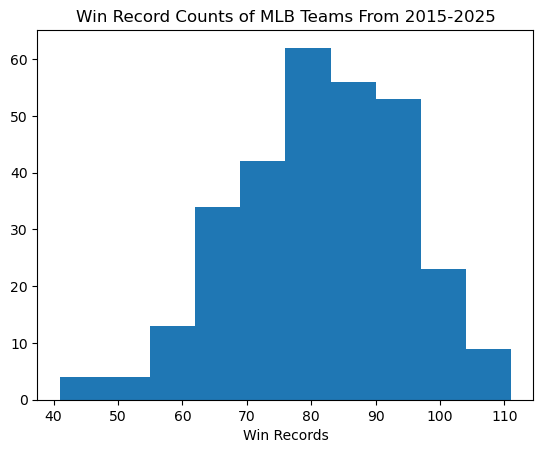

In [1503]:
# Visualizing the distribution of wins among teams
plt.hist(teams['W'])
plt.title("Win Record Counts of MLB Teams From 2015-2025")
plt.xlabel("Win Records")

Text(0, 0.5, 'Power Hit Counts')

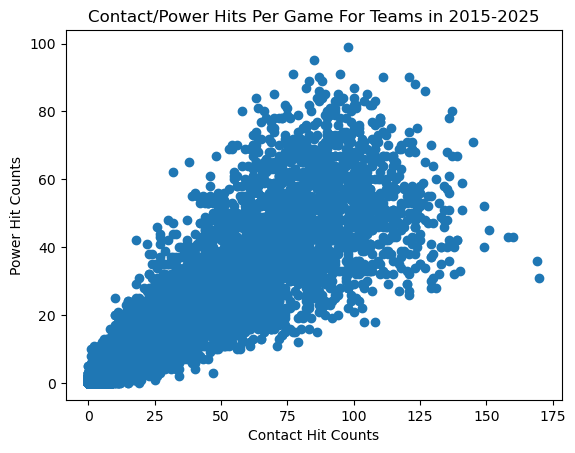

In [1504]:
# Visualizing the relationship between contact and power hits per game in the regular season
plt.scatter(batting['contact_hits'], batting['power_hits'])
plt.title("Contact/Power Hits Per Game For Teams in 2015-2025")
plt.xlabel("Contact Hit Counts")
plt.ylabel("Power Hit Counts")

Text(0, 0.5, 'Power Hit Counts')

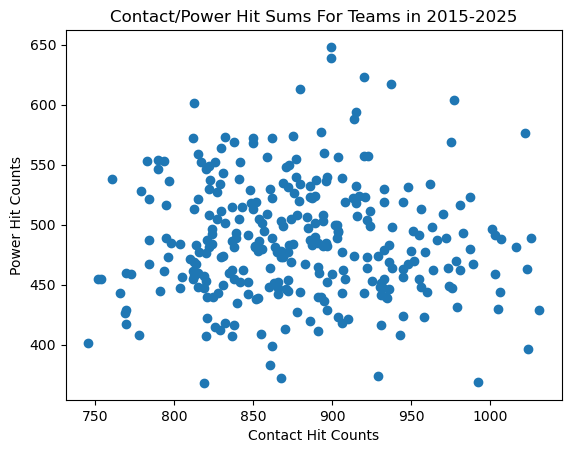

In [1505]:
# Visualizing the relationship between contact and power hit sums for teams in the regular season
plt.scatter(batting_hit_num['contact_hits_sum'], batting_hit_num['power_hits_sum'])
plt.title("Contact/Power Hit Sums For Teams in 2015-2025")
plt.xlabel("Contact Hit Counts")
plt.ylabel("Power Hit Counts")

In [1506]:
# Aggregating stats by year
year_bats_hit_num = conpow_adder(batting, 'yearID')

year_bats_hit_num.head()

,yearID,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%
0,2015,28016,18.853297,14090,9.481830,66.536836,33.463164
1,2016,27539,18.569791,14737,9.937289,65.140978,34.859022
2,2017,26918,18.017403,15297,10.238956,63.764065,36.235935
3,2018,26322,17.147883,14696,9.573941,64.171827,35.828173
4,2019,25947,16.537285,16092,10.256214,61.721259,38.278741


In [1507]:
year_post_bats_hit_num = conpow_adder(post_batting, 'yearID')

year_post_bats_hit_num.head()

,yearID,contact_hits_sum,contact_hits_mean,power_hits_sum,power_hits_mean,con_%,pow_%
0,2015,360,0.909091,194,0.489899,64.981949,35.018051
1,2016,342,0.888312,180,0.467532,65.517241,34.482759
2,2017,338,0.845000,221,0.552500,60.465116,39.534884
3,2018,325,0.790754,167,0.406326,66.056911,33.943089
4,2019,356,0.898990,216,0.545455,62.237762,37.762238


In [1508]:
# A helper function to add a horizontal line representing the average ratio of contact to power hits
def ratio_line(c_data, p_data):
    c_mean_val = np.mean(c_data)
    p_mean_val = np.mean(p_data)
    plt.axhline(c_mean_val, color='black', linestyle='--', linewidth=1.5)
    plt.text(9.6, c_mean_val-3, f'Avg. Ratio Divide:\n{c_mean_val:.2f}/{p_mean_val:.2f}', color='black', va='bottom', fontweight='bold')

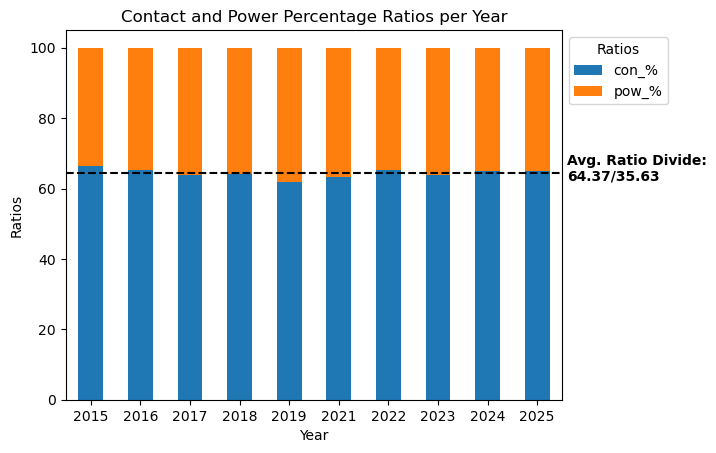

In [1509]:
# Visualizing the contact and power hit ratios per year
year_bats_hit_num_plot = year_bats_hit_num[['yearID', 'con_%', 'pow_%']].copy()
year_bats_hit_num_plot = year_bats_hit_num_plot.set_index('yearID')
year_bats_hit_num_plot.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])
ratio_line(year_bats_hit_num_plot['con_%'], year_bats_hit_num_plot['pow_%'])
plt.title('Contact and Power Percentage Ratios per Year')
plt.xlabel('Year')
plt.ylabel('Ratios')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1, 1),
    loc='upper left',
    fontsize='medium',
    ncol=1,
    title='Ratios'
)
plt.show()

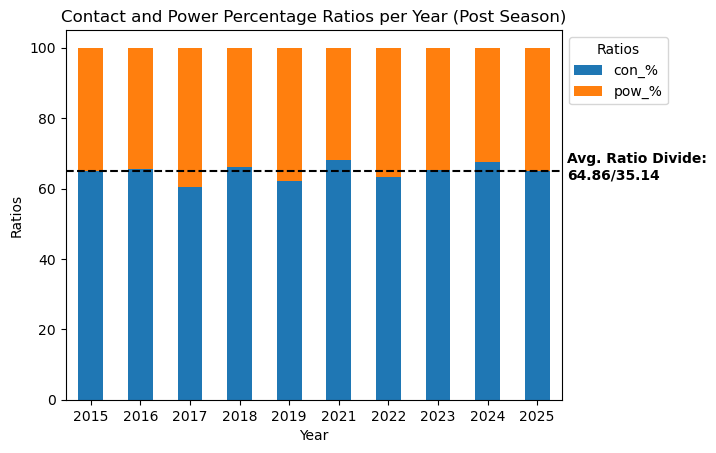

In [1510]:
# Visualizing the contact and power hit ratios per year for the postseason
year_post_bats_hit_num_plot = year_post_bats_hit_num[['yearID', 'con_%', 'pow_%']].copy()
year_post_bats_hit_num_plot = year_post_bats_hit_num_plot.set_index('yearID')
year_post_bats_hit_num_plot.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])
ratio_line(year_post_bats_hit_num_plot['con_%'], year_post_bats_hit_num_plot['pow_%'])
plt.title('Contact and Power Percentage Ratios per Year (Post Season)')
plt.xlabel('Year')
plt.ylabel('Ratios')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1, 1),
    loc='upper left',
    fontsize='medium',
    ncol=1,
    title='Ratios'
)
plt.show()

In [1511]:
# Calculating league-wide average contact and power hit ratios for the regular season
league_con_avg = batting_and_team_info['con_%'].mean()
league_pow_avg = batting_and_team_info['pow_%'].mean()

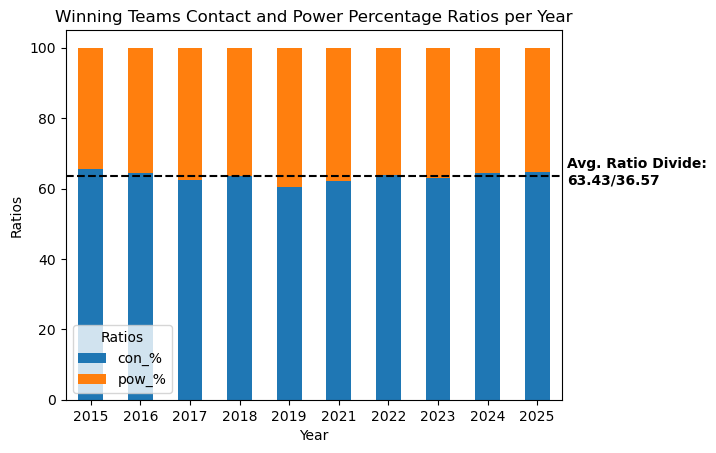

In [1512]:
# Visualizing the contact and power hit ratios per year for the winning teams (extra visualization)
winners_ratio_plot = winners_years[['yearID', 'con_%', 'pow_%']].copy()
winners_ratio_plot = winners_ratio_plot.set_index('yearID')
winners_ratio_plot.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])
ratio_line(winners_ratio_plot['con_%'], winners_ratio_plot['pow_%'])
plt.title('Winning Teams Contact and Power Percentage Ratios per Year')
plt.xlabel('Year')
plt.ylabel('Ratios')
plt.xticks(rotation=0)
plt.legend(
    loc='lower left',
    fontsize='medium',
    ncol=1,
    title='Ratios'
)
plt.show()

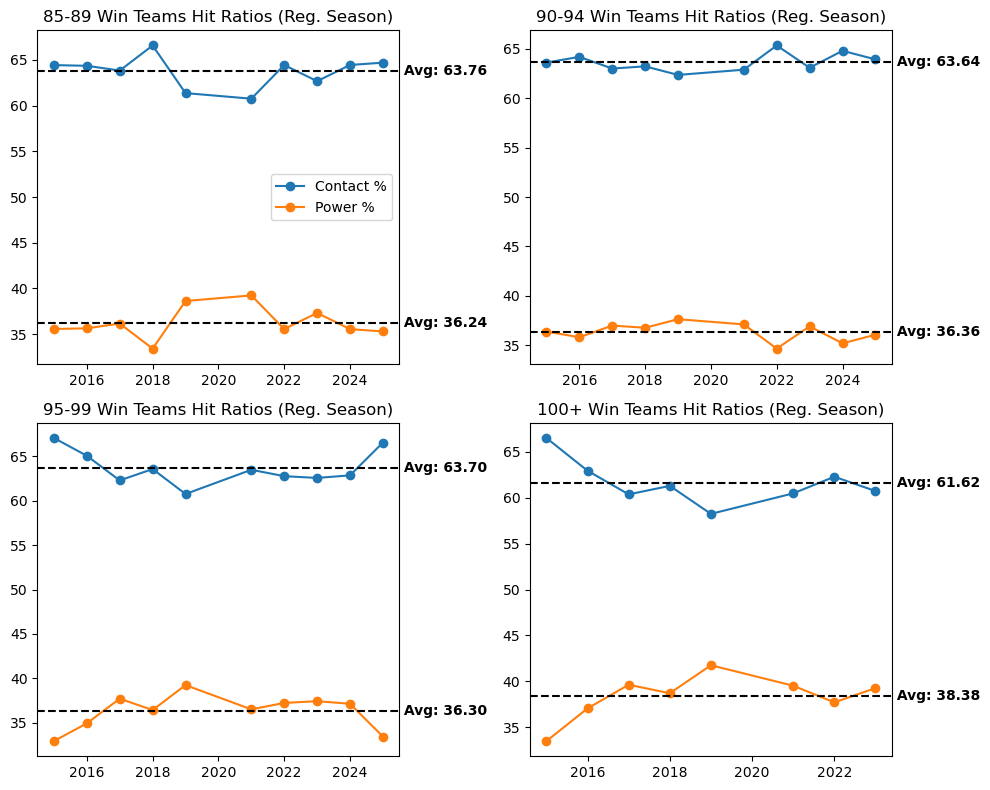

In [1513]:
# Visualizing the contact and power hit ratios per year for the winning teams in different win ranges
winners85_ratio_plot = winners85_years[['yearID', 'con_%', 'pow_%']].copy()
winners85_ratio_plot = winners85_ratio_plot.set_index('yearID')
winners90_ratio_plot = winners90_years[['yearID', 'con_%', 'pow_%']].copy()
winners90_ratio_plot = winners90_ratio_plot.set_index('yearID')
winners95_ratio_plot = winners95_years[['yearID', 'con_%', 'pow_%']].copy()
winners95_ratio_plot = winners95_ratio_plot.set_index('yearID')
winners100_ratio_plot = winners100_years[['yearID', 'con_%', 'pow_%']].copy()
winners100_ratio_plot = winners100_ratio_plot.set_index('yearID')

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

def add_mean_line(ax, data):
    mean_val = np.mean(data)
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1.5)
    ax.text(1, mean_val, f' Avg: {mean_val:.2f}', 
            color='black', fontweight='bold', va='center', ha='left',
            transform=ax.get_yaxis_transform())
    
axs[0, 0].plot(winners85_ratio_plot.index, winners85_ratio_plot['con_%'], marker='o', label='Contact %')
add_mean_line(axs[0, 0], winners85_ratio_plot['con_%'])
axs[0, 0].plot(winners85_ratio_plot.index, winners85_ratio_plot['pow_%'], marker='o', label='Power %')
add_mean_line(axs[0, 0], winners85_ratio_plot['pow_%'])
axs[0, 0].set_title('85-89 Win Teams Hit Ratios (Reg. Season)')
axs[0, 0].legend()

axs[0, 1].plot(winners90_ratio_plot.index, winners90_ratio_plot['con_%'], marker='o', label='Contact %')
add_mean_line(axs[0, 1], winners90_ratio_plot['con_%'])
axs[0, 1].plot(winners90_ratio_plot.index, winners90_ratio_plot['pow_%'], marker='o', label='Power %')
add_mean_line(axs[0, 1], winners90_ratio_plot['pow_%'])
axs[0, 1].set_title('90-94 Win Teams Hit Ratios (Reg. Season)')

axs[1, 0].plot(winners95_ratio_plot.index, winners95_ratio_plot['con_%'], marker='o', label='Contact %')
add_mean_line(axs[1, 0], winners95_ratio_plot['con_%'])
axs[1, 0].plot(winners95_ratio_plot.index, winners95_ratio_plot['pow_%'], marker='o', label='Power %')
add_mean_line(axs[1, 0], winners95_ratio_plot['pow_%'])
axs[1, 0].set_title('95-99 Win Teams Hit Ratios (Reg. Season)')

axs[1, 1].plot(winners100_ratio_plot.index, winners100_ratio_plot['con_%'], marker='o', label='Contact %')
add_mean_line(axs[1, 1], winners100_ratio_plot['con_%'])
axs[1, 1].plot(winners100_ratio_plot.index, winners100_ratio_plot['pow_%'], marker='o', label='Power %')
add_mean_line(axs[1, 1], winners100_ratio_plot['pow_%'])
axs[1, 1].set_title('100+ Win Teams Hit Ratios (Reg. Season)')

plt.tight_layout()
plt.show()

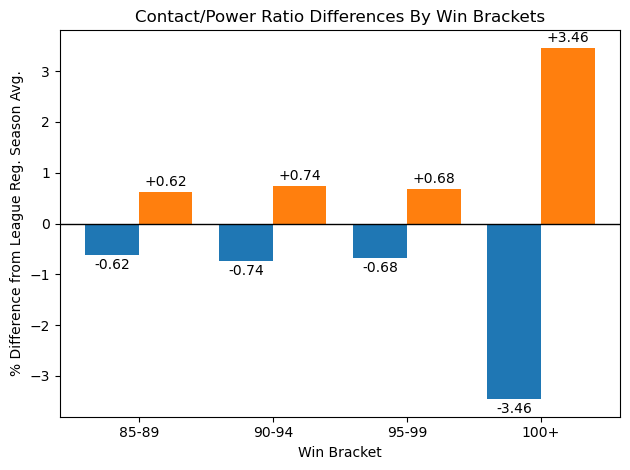

In [1514]:
# Diverging bar chart for differences in ratios by win brackets compared to league average
winning_types = ['85-89', '90-94', '95-99', '100+']
winning_contacts = [winners85_years['con_%'].mean(), winners90_years['con_%'].mean(), winners95_years['con_%'].mean(), winners100_up['con_%'].mean()]
winning_powers = [winners85_years['pow_%'].mean(), winners90_years['pow_%'].mean(), winners95_years['pow_%'].mean(), winners100_up['pow_%'].mean()]
winning_ratios = pd.DataFrame({
    'Wins in Season Type': winning_types,
    'Contact %': winning_contacts,
    'Power %': winning_powers
})
winning_ratios["Contact Diff"] = winning_ratios["Contact %"] - league_con_avg
winning_ratios["Power Diff"]   = winning_ratios["Power %"]   - league_pow_avg

x = np.arange(len(winning_ratios.index))
width = 0.4

contact_bars = plt.bar(x - width/2, winning_ratios["Contact Diff"], width, label="Contact %", color="#1f77b4")
power_bars = plt.bar(x + width/2, winning_ratios["Power Diff"],   width, label="Power %",   color="#ff7f0e")

for bar in contact_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.05 if height >= 0 else -0.05), f"{height:+.2f}", ha="center", va="bottom" if height >= 0 else "top")

for bar in power_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.05 if height >= 0 else -0.05), f"{height:+.2f}", ha="center", va="bottom" if height >= 0 else "top")

plt.axhline(0, color="black", linewidth=1)  # baseline
plt.xticks(x, winning_ratios['Wins in Season Type'])
plt.xlabel('Win Bracket')
plt.ylabel("% Difference from League Reg. Season Avg.")
plt.title("Contact/Power Ratio Differences By Win Brackets")
plt.tight_layout()
plt.show()

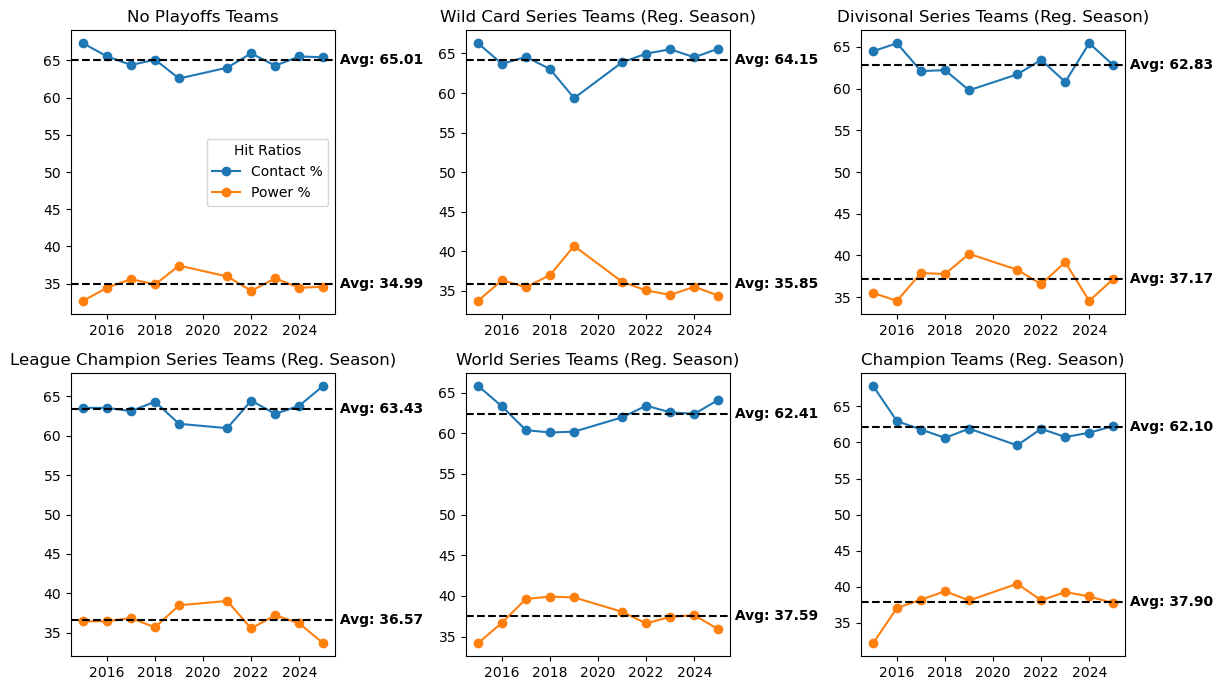

In [1515]:
# Visualizing the contact and power hit ratios per year for teams based on their postseason depth
reg_post_results_plot_year = batting_and_team_info[['yearID', 'teamID', 'con_%', 'pow_%', 'postseason_depth']].copy()
reg_post_results_plot_year = batting_and_team_info.groupby(['yearID', 'postseason_depth']).agg(
    contact=('con_%', 'mean'),
    power=('pow_%', 'mean')).reset_index()
reg_post_results_plot_year = reg_post_results_plot_year.rename(columns={'contact': 'con_%', 'power': 'pow_%'})
reg_post_results_plot_year = reg_post_results_plot_year.set_index('yearID')
reg_no_results_plot_year = reg_post_results_plot_year[reg_post_results_plot_year['postseason_depth'] == 0]
reg_WC_results_plot_year = reg_post_results_plot_year[reg_post_results_plot_year['postseason_depth'] == 1]
reg_DS_results_plot_year = reg_post_results_plot_year[reg_post_results_plot_year['postseason_depth'] == 2]
reg_CS_results_plot_year = reg_post_results_plot_year[reg_post_results_plot_year['postseason_depth'] == 3]
reg_WS_results_plot_year = reg_post_results_plot_year[reg_post_results_plot_year['postseason_depth'] == 4]
champions_results_plot_year = champions_by_year.set_index('yearID')

fig, axs = plt.subplots(2, 3, figsize=(12, 7))

axs[0, 0].plot(reg_no_results_plot_year.index, reg_no_results_plot_year['con_%'], marker='o', label='Contact %')
add_mean_line(axs[0, 0], reg_no_results_plot_year['con_%'])
axs[0, 0].plot(reg_no_results_plot_year.index, reg_no_results_plot_year['pow_%'], marker='o', label='Power %')
add_mean_line(axs[0, 0], reg_no_results_plot_year['pow_%'])
axs[0, 0].set_title('No Playoffs Teams')
axs[0, 0].legend(title='Hit Ratios')

axs[0, 1].plot(reg_WC_results_plot_year.index, reg_WC_results_plot_year['con_%'], marker='o', label='Contact %')
add_mean_line(axs[0, 1], reg_WC_results_plot_year['con_%'])
axs[0, 1].plot(reg_WC_results_plot_year.index, reg_WC_results_plot_year['pow_%'], marker='o', label='Power %')
add_mean_line(axs[0, 1], reg_WC_results_plot_year['pow_%'])
axs[0, 1].set_title('Wild Card Series Teams (Reg. Season)')

axs[0, 2].plot(reg_DS_results_plot_year.index, reg_DS_results_plot_year['con_%'], marker='o', label='Contact %')
add_mean_line(axs[0, 2], reg_DS_results_plot_year['con_%'])
axs[0, 2].plot(reg_DS_results_plot_year.index, reg_DS_results_plot_year['pow_%'], marker='o', label='Power %')
add_mean_line(axs[0, 2], reg_DS_results_plot_year['pow_%'])
axs[0, 2].set_title('Divisonal Series Teams (Reg. Season)')

axs[1, 0].plot(reg_CS_results_plot_year.index, reg_CS_results_plot_year['con_%'], marker='o', label='Contact %')
add_mean_line(axs[1, 0], reg_CS_results_plot_year['con_%'])
axs[1, 0].plot(reg_CS_results_plot_year.index, reg_CS_results_plot_year['pow_%'], marker='o', label='Power %')
add_mean_line(axs[1, 0], reg_CS_results_plot_year['pow_%'])
axs[1, 0].set_title('League Champion Series Teams (Reg. Season)')

axs[1, 1].plot(reg_WS_results_plot_year.index, reg_WS_results_plot_year['con_%'], marker='o', label='Contact %')
add_mean_line(axs[1, 1], reg_WS_results_plot_year['con_%'])
axs[1, 1].plot(reg_WS_results_plot_year.index, reg_WS_results_plot_year['pow_%'], marker='o', label='Power %')
add_mean_line(axs[1, 1], reg_WS_results_plot_year['pow_%'])
axs[1, 1].set_title('World Series Teams (Reg. Season)')

axs[1, 2].plot(champions_results_plot_year.index, champions_results_plot_year['con_%_regular'], marker='o', label='Contact %')
add_mean_line(axs[1, 2], champions_results_plot_year['con_%_regular'])
axs[1, 2].plot(champions_results_plot_year.index, champions_results_plot_year['pow_%_regular'], marker='o', label='Power %')
add_mean_line(axs[1, 2], champions_results_plot_year['pow_%_regular'])
axs[1, 2].set_title('Champion Teams (Reg. Season)')

plt.tight_layout()
plt.show()

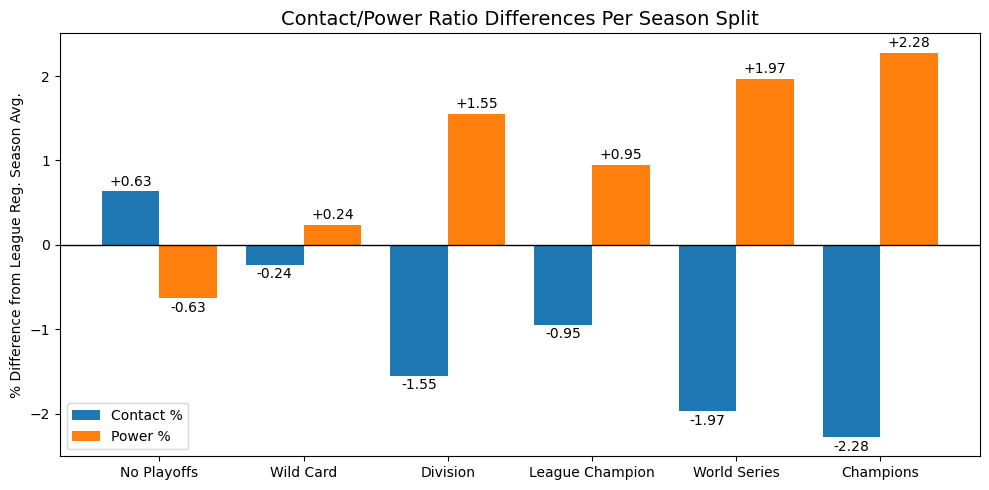

In [1516]:
# Diverging bar chart for differences in ratios by postseason depth compared to league average
plt.figure(figsize=(10, 5))

depth_types = ['No Playoffs', 'Wild Card', 'Division', 'League Champion', 'World Series', 'Champions']
depth_contacts = [reg_no_results_plot_year['con_%'].mean(), reg_WC_results_plot_year['con_%'].mean(), reg_DS_results_plot_year['con_%'].mean(), reg_CS_results_plot_year['con_%'].mean(), reg_WS_results_plot_year['con_%'].mean(), champions_results_plot_year['con_%_regular'].mean()]
depth_powers = [reg_no_results_plot_year['pow_%'].mean(), reg_WC_results_plot_year['pow_%'].mean(), reg_DS_results_plot_year['pow_%'].mean(), reg_CS_results_plot_year['pow_%'].mean(), reg_WS_results_plot_year['pow_%'].mean(), champions_results_plot_year['pow_%_regular'].mean()]
depth_ratios = pd.DataFrame({
    'Depth Type': depth_types,
    'Contact %': depth_contacts,
    'Power %': depth_powers
})
depth_ratios["Contact Diff"] = depth_contacts - league_con_avg
depth_ratios["Power Diff"] = depth_powers - league_pow_avg

x = np.arange(len(depth_ratios.index))
width = 0.4

contact_bars = plt.bar(x - width/2, depth_ratios["Contact Diff"], width, label="Contact %", color="#1f77b4")
power_bars = plt.bar(x + width/2, depth_ratios["Power Diff"],   width, label="Power %",   color="#ff7f0e")

for bar in contact_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.03 if height >= 0 else -0.03), f"{height:+.2f}", ha="center", va="bottom" if height >= 0 else "top")

for bar in power_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.03 if height >= 0 else -0.03), f"{height:+.2f}", ha="center", va="bottom" if height >= 0 else "top")

plt.axhline(0, color="black", linewidth=1)
plt.xticks(x, depth_ratios['Depth Type'])
plt.ylabel("% Difference from League Reg. Season Avg.")
plt.title("Contact/Power Ratio Differences Per Season Split", fontsize=14)
plt.legend(
    loc='lower left',
    fontsize='medium',
    ncol=1)

plt.tight_layout()
plt.show()

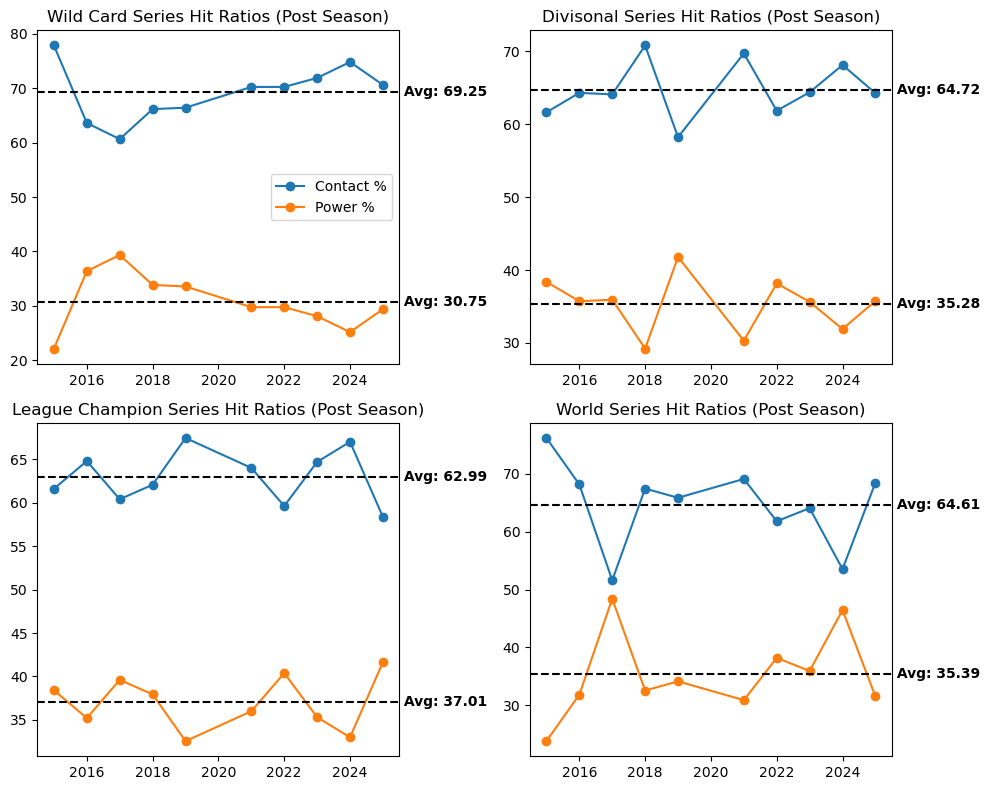

In [1517]:
# Visualizing the contact and power hit ratios per year for teams based on their postseason round type (extra visualization)
series_results_plot_year = post_batting_results.groupby(['yearID', 'round_type']).agg(
    contact=('con_%', 'mean'),
    power=('pow_%', 'mean')).reset_index()
series_results_plot_year = series_results_plot_year.rename(columns={'contact': 'con_%', 'power': 'pow_%'})
series_results_plot_year = series_results_plot_year.set_index('yearID')
WC_series_results_plot_year = series_results_plot_year[series_results_plot_year['round_type'] == 'WC']
DS_series_results_plot_year = series_results_plot_year[series_results_plot_year['round_type'] == 'DS']
CS_series_results_plot_year = series_results_plot_year[series_results_plot_year['round_type'] == 'CS']
WS_series_results_plot_year = series_results_plot_year[series_results_plot_year['round_type'] == 'WS']

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].plot(WC_series_results_plot_year.index, WC_series_results_plot_year['con_%'], marker='o', label='Contact %')
add_mean_line(axs[0, 0], WC_series_results_plot_year['con_%'])
axs[0, 0].plot(WC_series_results_plot_year.index, WC_series_results_plot_year['pow_%'], marker='o', label='Power %')
add_mean_line(axs[0, 0], WC_series_results_plot_year['pow_%'])
axs[0, 0].set_title('Wild Card Series Hit Ratios (Post Season)')
axs[0, 0].legend()

axs[0, 1].plot(DS_series_results_plot_year.index, DS_series_results_plot_year['con_%'], marker='o', label='Contact %')
add_mean_line(axs[0, 1], DS_series_results_plot_year['con_%'])
axs[0, 1].plot(DS_series_results_plot_year.index, DS_series_results_plot_year['pow_%'], marker='o', label='Power %')
add_mean_line(axs[0, 1], DS_series_results_plot_year['pow_%'])
axs[0, 1].set_title('Divisonal Series Hit Ratios (Post Season)')

axs[1, 0].plot(CS_series_results_plot_year.index, CS_series_results_plot_year['con_%'], marker='o', label='Contact %')
add_mean_line(axs[1, 0], CS_series_results_plot_year['con_%'])
axs[1, 0].plot(CS_series_results_plot_year.index, CS_series_results_plot_year['pow_%'], marker='o', label='Power %')
add_mean_line(axs[1, 0], CS_series_results_plot_year['pow_%'])
axs[1, 0].set_title('League Champion Series Hit Ratios (Post Season)')

axs[1, 1].plot(WS_series_results_plot_year.index, WS_series_results_plot_year['con_%'], marker='o', label='Contact %')
add_mean_line(axs[1, 1], WS_series_results_plot_year['con_%'])
axs[1, 1].plot(WS_series_results_plot_year.index, WS_series_results_plot_year['pow_%'], marker='o', label='Power %')
add_mean_line(axs[1, 1], WS_series_results_plot_year['pow_%'])
axs[1, 1].set_title('World Series Hit Ratios (Post Season)')

plt.tight_layout()
plt.show()

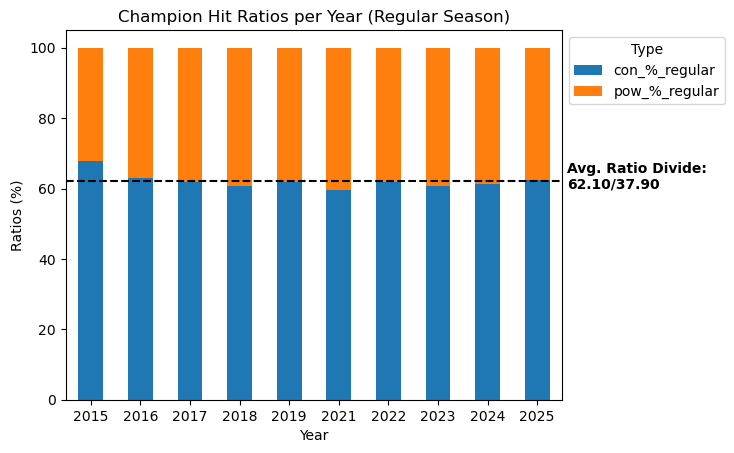

In [1518]:
# Visualizing the contact and power hit ratios per year for the champion teams in the regular season (extra visualization)
champions_by_year_plot = champions_by_year[['yearID', 'con_%_regular', 'pow_%_regular']].copy()
champions_by_year_plot = champions_by_year_plot.set_index('yearID')
champions_by_year_plot.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])
ratio_line(champions_by_year['con_%_regular'], champions_by_year['pow_%_regular'])
plt.title('Champion Hit Ratios per Year (Regular Season)')
plt.xlabel('Year')
plt.ylabel('Ratios (%)')
plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1, 1),
    loc='upper left',
    fontsize='medium',
    ncol=1,
    title='Type'
)
plt.show()

In [1519]:
# Extra code for adding a value of 5 to postseason depth for the champions of each year
# Was removed since it wasn't improving models
'''for index, row in champions_by_year.iterrows():
    champion = row['teamID']
    year = row['yearID']
    batting_and_team_info.loc[(batting_and_team_info['teamID'] == champion) & (batting_and_team_info['yearID'] == year), 'postseason_depth'] = 5'''

"for index, row in champions_by_year.iterrows():\n    champion = row['teamID']\n    year = row['yearID']\n    batting_and_team_info.loc[(batting_and_team_info['teamID'] == champion) & (batting_and_team_info['yearID'] == year), 'postseason_depth'] = 5"

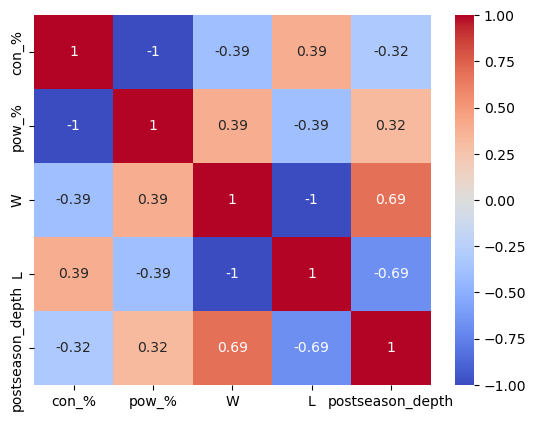

In [1520]:
# Correlation Matrix

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['con_%', 'pow_%', 'W', 'L', 'postseason_depth']
corr = batting_and_team_info[num_cols].corr(method='pearson')

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score, root_mean_squared_error, mean_absolute_error,
    accuracy_score, roc_auc_score, f1_score
)
import mord as m # Used for the ordinal regression

In [1522]:
# Linear Regression Wins

pipe_lin_wins = Pipeline([
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

X = batting_and_team_info[['con_%', 'pow_%']]
y = batting_and_team_info['W']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=7
)

pipe_lin_wins.fit(X_train, y_train)
pred_lin = pipe_lin_wins.predict(X_test)

print("Linear Regression (Wins)\n")
print("R2:", r2_score(y_test, pred_lin))
print("RMSE:", root_mean_squared_error(y_test, pred_lin))
print("MAE:", mean_absolute_error(y_test, pred_lin))

coef = pipe_lin_wins.named_steps['linreg'].coef_
intercept = pipe_lin_wins.named_steps['linreg'].intercept_

print("\nCoefficients:", coef)
print("Intercept:", intercept)

Linear Regression (Wins)

R2: 0.09209778376603694
RMSE: 11.167564296797153
MAE: 8.845109055961878

Coefficients: [-2.76264463  2.76264463]
Intercept: 81.38571428571429


In [1523]:
# Random Forest Wins

pipe_rf_wins = Pipeline([
    ('rf', RandomForestRegressor(
        n_estimators=1000,
        random_state=7
    ))
])

pipe_rf_wins.fit(X_train, y_train)
pred_rf = pipe_rf_wins.predict(X_test)

print("Random Forest (Wins)\n")
print("R2:", r2_score(y_test, pred_rf))
print("RMSE:", root_mean_squared_error(y_test, pred_rf))
print("MAE:", mean_absolute_error(y_test, pred_rf))

importances = pipe_rf_wins.named_steps['rf'].feature_importances_
pd.Series(importances, index=X_train.columns)

Random Forest (Wins)

R2: -0.6775937863284507
RMSE: 15.180368982852677
MAE: 11.77201111111111


con_%    0.501932
pow_%    0.498068
dtype: float64

In [1524]:
# Linear Regression Post-Season Depth

pipe_lin_depth = Pipeline([
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

X = batting_and_team_info[['con_%', 'pow_%']]
y = batting_and_team_info['postseason_depth']

Xd_train, Xd_test, yd_train, yd_test = train_test_split(X, y, test_size=0.3, random_state=7)

pipe_lin_depth.fit(Xd_train, yd_train)
pred_lin = pipe_lin_depth.predict(Xd_test)

print("Linear Regression (Post-Season Depth)\n")
print("R2:", r2_score(yd_test, pred_lin))
print("RMSE:", root_mean_squared_error(yd_test, pred_lin))
print("MAE:", mean_absolute_error(yd_test, pred_lin))

coef = pipe_lin_depth.named_steps['linreg'].coef_
intercept = pipe_lin_depth.named_steps['linreg'].intercept_

print("\nCoefficients:", coef)
print("Intercept:", intercept)

Linear Regression (Post-Season Depth)

R2: 0.0197650148437869
RMSE: 1.162598438641678
MAE: 0.9280018081450796

Coefficients: [-0.2327634  0.2327634]
Intercept: 0.8523809523809522


In [1525]:
# Random Forest Regressor Post-Season Depth

pipe_rf_depth = Pipeline([
    ('rf', RandomForestRegressor(
        n_estimators=1000,
        random_state=7
    ))
])

Xd_train, Xd_test, yd_train, yd_test = train_test_split(X, y, test_size=0.3, random_state=7)

pipe_rf_depth.fit(Xd_train, yd_train)
pred_rf = pipe_rf_depth.predict(Xd_test)

print("Random Forest (Post-Season Depth)\n")
print("R2:", r2_score(yd_test, pred_rf))
print("RMSE:", root_mean_squared_error(yd_test, pred_rf))
print("MAE:", mean_absolute_error(yd_test, pred_rf))

importances = pipe_rf_depth.named_steps['rf'].feature_importances_
pd.Series(importances, index=X_train.columns)

Random Forest (Post-Season Depth)

R2: -0.6618612006446412
RMSE: 1.513777376117256
MAE: 1.1037444444444444


con_%    0.500189
pow_%    0.499811
dtype: float64

In [1526]:
# Random Forest Classifier Post-Season Depth

rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=7,
    class_weight='balanced'
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)

print("\nRandom Forest Classifier:\n")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf, multi_class='ovr'))

importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
print("\nFeature Importances:")
print(importances.sort_values(ascending=False))


Random Forest Classifier:

Accuracy: 0.35555555555555557
F1 Score: 0.37677514888137775
ROC-AUC: 0.4018015763097999

Feature Importances:
pow_%    0.500539
con_%    0.499461
dtype: float64


In [1527]:
# Regular Logistic Regression Post-Season Depth

pipe_log_playoffs = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

X = batting_and_team_info[['con_%', 'pow_%']]
y = batting_and_team_info['postseason_depth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

pipe_log_playoffs.fit(X_train, y_train)
pred = pipe_log_playoffs.predict(X_test)
prob = pipe_log_playoffs.predict_proba(X_test)

print("Logistic Regression (Post-Season Depth)\n")
print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, prob, multi_class='ovr'))

coef = pipe_log_playoffs.named_steps['logreg'].coef_
print("Coefficients:", coef)

Logistic Regression (Post-Season Depth)

Accuracy: 0.6444444444444445
F1: 0.5051051051051051
ROC-AUC: 0.5868476223987197
Coefficients: [[ 0.30664603 -0.30664603]
 [ 0.13772928 -0.13772928]
 [-0.03408825  0.03408825]
 [-0.07874151  0.07874151]
 [-0.33154555  0.33154555]]


In [1528]:
# Ordinal Logistic Regression Post-Season Depth (With Post-Season Depth 0-4)

scaler = StandardScaler()

X = batting_and_team_info[['con_%', 'pow_%']]
y = batting_and_team_info['postseason_depth'].astype(int)

X_scaled = scaler.fit_transform(X)

Xo_train, Xo_test, yo_train, yo_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=7
)

ord_model = m.LogisticAT(alpha=1.0)
ord_model.fit(Xo_train, yo_train)

yo_pred = ord_model.predict(Xo_test)
yo_prob = ord_model.predict_proba(Xo_test)

print("Ordinal Regression\n")
print("Accuracy:", accuracy_score(yo_test, yo_pred))
print("F1:", f1_score(yo_test, yo_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(yo_test, yo_prob, multi_class='ovr'))
print("\nCoefficients:", ord_model.coef_)
print("Thresholds:", ord_model.theta_)

Ordinal Regression

Accuracy: 0.6333333333333333
F1: 0.548792270531401
ROC-AUC: 0.5714841107389117

Coefficients: [-0.39578267  0.39578267]
Thresholds: [0.65684526 1.13507246 2.0682736  2.70694455]


In [1529]:
# Cross Validation

from sklearn.model_selection import cross_val_score

logreg = LogisticRegression(max_iter=500)

scores = cross_val_score(logreg, batting_and_team_info[['con_%', 'pow_%']], batting_and_team_info['postseason_depth'], cv=10)
print("10-fold cross validation accuracy scores: {}".format(scores))
print("10-fold cross validation average accuracy scores: {:.2f}".format(scores.mean(axis=0)))

10-fold cross validation accuracy scores: [0.66666667 0.66666667 0.63333333 0.63333333 0.66666667 0.66666667
 0.63333333 0.63333333 0.63333333 0.56666667]
10-fold cross validation average accuracy scores: 0.64


In [ ]:
# Grid Search Method for Logistic Regression

from sklearn.linear_model import LogisticRegression

X = batting_and_team_info[['con_%', 'pow_%']]
y = batting_and_team_info['postseason_depth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)
sc= StandardScaler()

from sklearn.model_selection import GridSearchCV

param_grid = {'C':[0.0000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
             'penalty': ['l1', 'l2'],
             'solver': ['liblinear', 'saga']}

grid = GridSearchCV(LogisticRegression(), param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best grid score: {:.2f}".format(grid.best_score_))
print("Grid test score: {:.2f}".format(grid.score(X_test, y_test)))
print("Best grid parameters: {}".format(grid.best_params_))

/Users/swagebs77/miniforge3/envs/usableai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/swagebs77/miniforge3/envs/usableai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/swagebs77/miniforge3/envs/usableai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', 

Best grid score: 0.64
Grid test score: 0.64
Best grid parameters: {'C': 1e-07, 'penalty': 'l1', 'solver': 'saga'}


/Users/swagebs77/miniforge3/envs/usableai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/swagebs77/miniforge3/envs/usableai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/swagebs77/miniforge3/envs/usableai/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/swagebs77/miniforge3/envs/usableai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'p

In [1531]:
# Values here for Grid Search to look past the warnings

print("Best grid score: {:.2f}".format(grid.best_score_))
print("Grid test score: {:.2f}".format(grid.score(X_test, y_test)))
print("Best grid parameters: {}".format(grid.best_params_))

Best grid score: 0.64
Grid test score: 0.64
Best grid parameters: {'C': 1e-07, 'penalty': 'l1', 'solver': 'saga'}


In [ ]:
# Last minute observation to see if XGBoost provided anything, however no real improvement was shown

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=7,
    use_label_encoder=False,
    eval_metric='mlogloss')

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

/Users/swagebs77/miniforge3/envs/usableai/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [23:34:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.5555555555555556
              precision    recall  f1-score   support

           0       0.69      0.83      0.75        58
           1       0.00      0.00      0.00         9
           2       0.25      0.08      0.12        12
           3       0.17      0.12      0.14         8
           4       0.00      0.00      0.00         3

    accuracy                           0.56        90
   macro avg       0.22      0.21      0.20        90
weighted avg       0.49      0.56      0.51        90

